# 10.1 — Merton estructural y modelos de intensidad

Arranca M10. Dos familias de modelos de crédito con filosofías opuestas: **Merton**
(1974) deriva el default de la estructura de capital de la firma (mecanismo económico
explícito); los **modelos de intensidad** (reducidos) tratan el default como el primer
salto de un proceso de Poisson, sin mecanismo económico, pero calibrables directamente a
spreads de mercado — el enfoque dominante en la práctica de pricing de crédito (M10.2+).

## 0. Configuración

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import brentq
import matplotlib.pyplot as plt

from qflib.black import bs_price
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 1. Merton estructural

El valor de la firma $V_t$ sigue GBM bajo la medida risk-neutral. La deuda es un bono
cupón cero de cara $D$ a vencimiento $T$: si $V_T\ge D$, los tenedores de deuda reciben
$D$ y el equity recibe $V_T-D$; si $V_T<D$, la firma defaultea, la deuda recibe $V_T$
(todo lo que queda) y el equity recibe 0. El **equity es exactamente una call** sobre
$V_T$ con strike $D$ (Black-Scholes, `qflib.black.bs_price`); la deuda es
$\text{Deuda}_0=V_0-\text{Equity}_0$ (identidad contable — se reparte todo el valor de la
firma). La probabilidad de default risk-neutral es $N(-d_2)$ de la misma fórmula BS.

In [2]:
def merton_equity(V0, D, r, sigma_V, T):
    return bs_price(V0, D, r, 0.0, sigma_V, T, kind="call")


def merton_default_prob(V0, D, r, sigma_V, T):
    d1 = (np.log(V0 / D) + (r + 0.5 * sigma_V ** 2) * T) / (sigma_V * np.sqrt(T))
    d2 = d1 - sigma_V * np.sqrt(T)
    return norm.cdf(-d2)


V0, D, r, sigma_V, T = 100.0, 80.0, 0.04, 0.25, 5.0
equity0 = merton_equity(V0, D, r, sigma_V, T)
debt0 = V0 - equity0
pd_merton = merton_default_prob(V0, D, r, sigma_V, T)

print(f"equity_0={equity0:.4f}  deuda_0={debt0:.4f}  V0={V0}  (equity+deuda-V0={equity0+debt0-V0:.2e})")
print(f"probabilidad de default (riesgo-neutral): {pd_merton:.4%}")

equity_0=40.2340  deuda_0=59.7660  V0=100.0  (equity+deuda-V0=0.00e+00)
probabilidad de default (riesgo-neutral): 31.6527%


### Demo 1 — probabilidad de default vs apalancamiento y volatilidad de activos

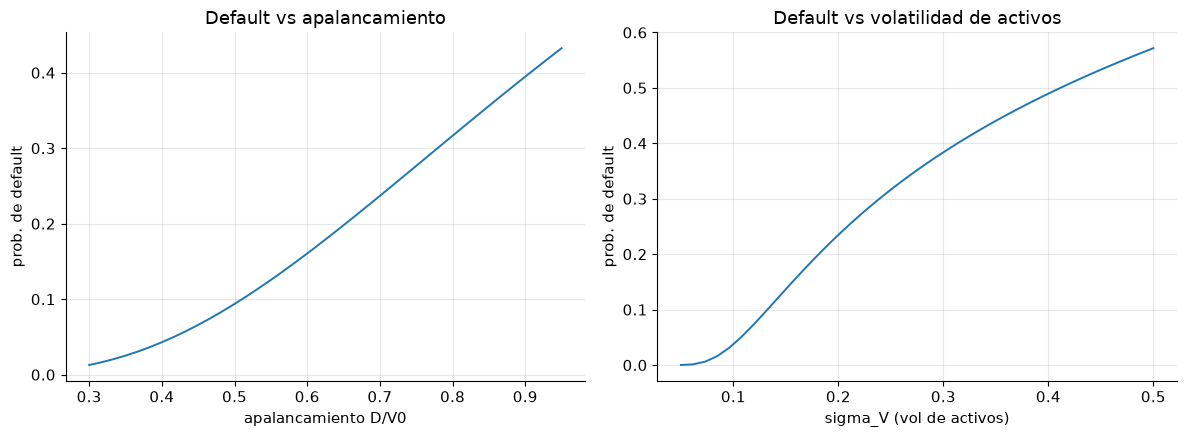

mayor apalancamiento y mayor volatilidad de activos elevan la probabilidad de default --
consistente con la intuicion: firmas mas endeudadas o mas riesgosas defaultean mas seguido.


In [3]:
leverage_grid = np.linspace(0.3, 0.95, 40)
pd_by_leverage = [merton_default_prob(V0, leverage * V0, r, sigma_V, T) for leverage in leverage_grid]

sigma_grid = np.linspace(0.05, 0.5, 40)
pd_by_sigma = [merton_default_prob(V0, D, r, s, T) for s in sigma_grid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(leverage_grid, pd_by_leverage)
axes[0].set_xlabel("apalancamiento D/V0"); axes[0].set_ylabel("prob. de default")
axes[0].set_title("Default vs apalancamiento")

axes[1].plot(sigma_grid, pd_by_sigma)
axes[1].set_xlabel("sigma_V (vol de activos)"); axes[1].set_ylabel("prob. de default")
axes[1].set_title("Default vs volatilidad de activos")
fig.tight_layout(); plt.show()

print("mayor apalancamiento y mayor volatilidad de activos elevan la probabilidad de default --")
print("consistente con la intuicion: firmas mas endeudadas o mas riesgosas defaultean mas seguido.")

## 2. Modelos de intensidad (reducidos)

El default es el primer salto de un proceso de Poisson con intensidad (hazard rate)
$\lambda_t$: $P(\tau>t)=\exp\left(-\int_0^t\lambda_s\,ds\right)$. Con $\lambda$
**constante**, $P(\tau>t)=e^{-\lambda t}$, simulable exactamente por inversión de CDF
(reusa 0.3): $\tau=-\ln(U)/\lambda$, $U\sim\text{Unif}(0,1)$.

In [4]:
lam_const = 0.02
n_paths = 200_000
U = rng.uniform(size=n_paths)
tau_sim = -np.log(U) / lam_const

t_check = 3.0
surv_sim = np.mean(tau_sim > t_check)
surv_exact = np.exp(-lam_const * t_check)
se_surv = np.sqrt(surv_exact * (1 - surv_exact) / n_paths)
z_const = (surv_sim - surv_exact) / se_surv

print(f"intensidad constante lambda={lam_const}: P(tau>{t_check}) simulada={surv_sim:.5f}, "
      f"exacta={surv_exact:.5f}, z={z_const:.2f}")

intensidad constante lambda=0.02: P(tau>3.0) simulada=0.94148, exacta=0.94176, z=-0.54


### Demo 2 — intensidad determinista dependiente del tiempo

intensidad lambda(t)=0.01+0.005t: P(tau>4.0) simulada=0.92400, exacta (integracion numerica)=0.92312, z=0.74


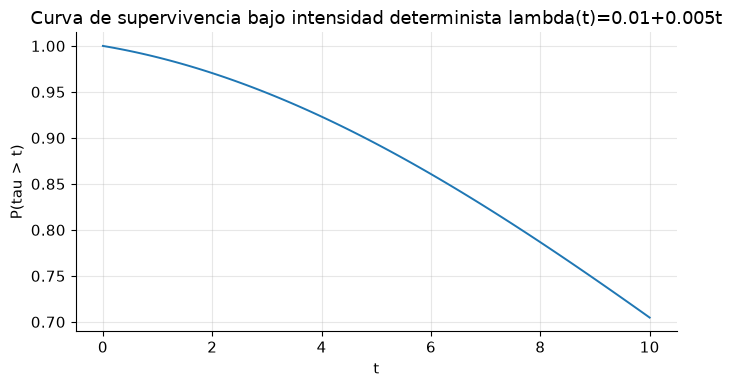

In [5]:
def lam_t(t):
    return 0.01 + 0.005 * t


def cum_hazard(t):
    return quad(lam_t, 0, t)[0]


t_check2 = 4.0
surv_exact2 = np.exp(-cum_hazard(t_check2))

n_paths2 = 50_000
E = rng.exponential(size=n_paths2)  # tau tal que cum_hazard(tau) = E ~ Exp(1) (inversion de CDF generalizada)
tau_sim2 = np.array([brentq(lambda t: cum_hazard(t) - e, 0.0, 200.0) for e in E])

surv_sim2 = np.mean(tau_sim2 > t_check2)
se_surv2 = np.sqrt(surv_exact2 * (1 - surv_exact2) / n_paths2)
z_timedep = (surv_sim2 - surv_exact2) / se_surv2

print(f"intensidad lambda(t)=0.01+0.005t: P(tau>{t_check2}) simulada={surv_sim2:.5f}, "
      f"exacta (integracion numerica)={surv_exact2:.5f}, z={z_timedep:.2f}")

t_grid = np.linspace(0, 10, 100)
surv_curve = np.array([np.exp(-cum_hazard(t)) for t in t_grid])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_grid, surv_curve)
ax.set_xlabel("t"); ax.set_ylabel("P(tau > t)")
ax.set_title("Curva de supervivencia bajo intensidad determinista lambda(t)=0.01+0.005t")
fig.tight_layout(); plt.show()

## 3. Validación

In [6]:
check1 = abs(equity0 + debt0 - V0) < 1e-10
print(f"1. identidad contable Merton (equity+deuda=V0): diff={equity0+debt0-V0:.2e} (<1e-10? {check1})")

check2 = abs(z_const) <= 3.0
print(f"2. supervivencia (intensidad constante) simulada vs exacta: z={z_const:.2f} (<=3? {check2})")

check3 = abs(z_timedep) <= 3.0
print(f"3. supervivencia (intensidad determinista) simulada vs exacta: z={z_timedep:.2f} (<=3? {check3})")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 dentro de tolerancia.")

1. identidad contable Merton (equity+deuda=V0): diff=0.00e+00 (<1e-10? True)
2. supervivencia (intensidad constante) simulada vs exacta: z=-0.54 (<=3? True)
3. supervivencia (intensidad determinista) simulada vs exacta: z=0.74 (<=3? True)

Validacion completa: 3/3 dentro de tolerancia.


## Referencias

- Merton, R. (1974). *On the Pricing of Corporate Debt: The Risk Structure of Interest
  Rates*. Journal of Finance, 29(2), 449-470.
- Jarrow, R., Turnbull, S. (1995). *Pricing Derivatives on Financial Securities Subject to
  Credit Risk*. Journal of Finance, 50(1), 53-85.